# Does the Euclid PSF model affect the photometry comparison?

The linked upstream notebook uses **Q1 MER GRID-PSF samples**, normalized to unit finite-stamp sum and selected by nearest angular distance at each source. It uses separate PSF fields in VIS, Y, J and H. CATALOG-PSF is supported as an alternative, but is not its default.

We retrieved 19 nearby GRID samples per band from **the matching EDF-S MER tile 102044185**, around RA 53.25555525°, Dec −28.06391707°. These are local archive products, not the notebook's EDF-N example PSFs. The upstream extractor is unchanged and the S3 paths/tile IDs remain in each cached NPZ.

## Paired experiment

Generate 128 two-source blends (256 sources) using the full archive kernels in Euclid, then fit **the identical noisy images** under three assumed-PSF conditions:

1. **Original Gaussian:** the global Gaussian widths from our previous benchmark.
2. **Local-FWHM Gaussian:** circular pixelized Gaussians using the nearest archive sample's reported FWHM. This is a core-width control, not a wing model.
3. **Archive GRID-PSF:** the full nearest stamp, including wings and asymmetry.

Tractor, the image-prior mixture, and the foundation-prior mixture each run all three conditions. Every source has the same known fixed position. Foundation features are freshly encoded from the new images; both learned priors are then held identical across PSF conditions. No retraining or test-driven tuning occurs. The Gaussian-based ellipse initializer is held fixed, isolating changes to the convolution model.

Euclid truth uses an analytic exponential core/disk Fourier profile, whereas the mixture fitter uses Gaussian components and Tractor uses its own profile library. A PSF stamp already includes the delivered pixel response: we do **not** integrate it over another pixel. Padding avoids FFT wraparound, and cropped source footprints are not renormalized. The three pixel-PSF unit tests and a separate Tractor cross-renderer test verify these conventions.

Rubin retains the previous Gaussian truth and fitting PSFs in all conditions. Its fluxes are still measured in all ten-band fits, but this experiment tests the **Euclid** PSF choice.

EDF-S, MER tile 102044185; 19 grid locations around RA 53.25555525 Dec -28.06391707
Sources: 256  | conditions: 3 | photometry methods: 3


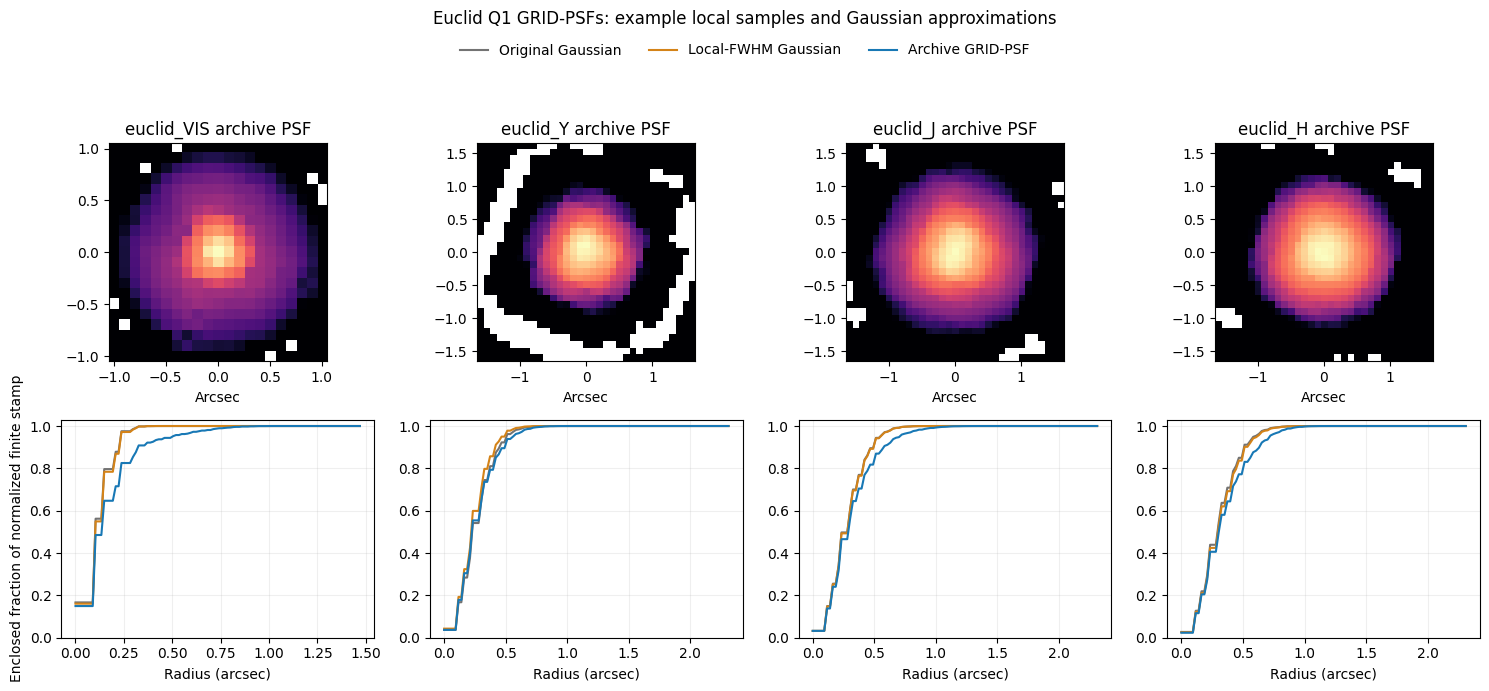

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'models/photometry/self_supervised').is_dir())
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
OUT = ROOT/'models/photometry/self_supervised/runs/psf_study'
from models.photometry.self_supervised.psf_report import make_report
stats, paired, figures = make_report(OUT)
print(json.loads((OUT/'protocol.json').read_text())['field'])
print('Sources:', int(stats.n.iloc[0]), ' | conditions: 3 | photometry methods: 3')
display(figures[0]); plt.close(figures[0])

## Accuracy and paired PSF effect

Use all signed flux measurements for median absolute fractional error. The NISP summary is the equal-weight average of the Y/J/H per-band medians. Bootstrap intervals resample complete two-source blends (2,000 draws). Negative grid-minus-Gaussian differences favor the archive stamps; intervals crossing zero are inconclusive on this sample.

In [2]:
euclid = stats[stats.band.str.startswith('euclid_')]
display(euclid.pivot(index=['model','band'], columns='condition', values='median_absolute_error_percent').round(2))
nisp = euclid[euclid.band.isin(['euclid_Y','euclid_J','euclid_H'])].groupby(['model','condition']).median_absolute_error_percent.mean().unstack()
print('NISP mean of median absolute percentage errors:')
display(nisp.round(2))
display(paired[(paired.band=='NISP_YJH')].round(3))
print('Signed median flux biases (%), for diagnosis:')
display(euclid.pivot(index=['model','band'], columns='condition', values='bias_percent').round(2))

NISP mean of median absolute percentage errors:
Signed median flux biases (%), for diagnosis:


condition               core_gaussian  gaussian   grid
model       band                                      
foundation  euclid_H             9.34      9.44   9.55
            euclid_J             9.51      9.58   9.85
            euclid_VIS          18.46     18.53  18.26
            euclid_Y            13.60     13.79  12.94
image       euclid_H             9.99     10.44   9.76
            euclid_J             9.87      9.80   9.50
            euclid_VIS          18.29     17.94  18.29
            euclid_Y            13.24     12.78  12.00
tractor_vis euclid_H            22.74     20.24  18.02
            euclid_J            22.73     22.18  20.06
            euclid_VIS          46.33     44.90  41.89
            euclid_Y            23.46     21.60  21.92

condition,core_gaussian,gaussian,grid
model,,,
foundation,10.82,10.94,10.78
image,11.04,11.01,10.42
tractor_vis,22.98,21.34,20.00


,model,band,baseline,difference_pp,ci_low_pp,ci_high_pp
4,tractor_vis,NISP_YJH,gaussian,-1.343,-3.456,1.274
9,tractor_vis,NISP_YJH,core_gaussian,-2.980,-4.864,-0.315
14,image,NISP_YJH,gaussian,-0.587,-1.165,0.331
19,image,NISP_YJH,core_gaussian,-0.617,-1.286,0.326
24,foundation,NISP_YJH,gaussian,-0.158,-1.004,0.409
29,foundation,NISP_YJH,core_gaussian,-0.036,-1.034,0.477


condition               core_gaussian  gaussian   grid
model       band                                      
foundation  euclid_H             1.43      1.58   2.53
            euclid_J             0.73      0.45   1.90
            euclid_VIS           6.03      6.66   8.27
            euclid_Y             5.92      5.56   5.70
image       euclid_H             1.93      1.78   2.32
            euclid_J             0.81      0.70   1.96
            euclid_VIS           5.79      6.21   8.23
            euclid_Y             6.51      6.63   6.12
tractor_vis euclid_H            -8.97     -8.67  -9.38
            euclid_J           -10.29    -10.90 -12.87
            euclid_VIS         -13.22    -13.62 -20.12
            euclid_Y            -6.15     -5.60 -10.31

## Offset versus magnitude

Rows compare Tractor, the image-only mixture, and the foundation mixture. Within each panel, only the assumed PSF changes. Lines are 51-source running medians; shading is the central 16th–84th percentile distribution. Magnitude offsets share a common positive-flux subset across all nine combinations; the numerical flux statistics retain nonpositive measurements. The horizontal axis is **true AB magnitude**, using the verified original science-image `MAGZERO` values (VIS 24.6, Y 29.8, J 30.0, H 29.9). Cached pixel units were checked against 81 original archive pixels in each band. The vertical axis is **ΔAB magnitude = measured AB − true AB**. Show sources with true AB magnitude ≥20; no sparse bright bins are created.

All-band signed flux results (Rubin PSFs unchanged):


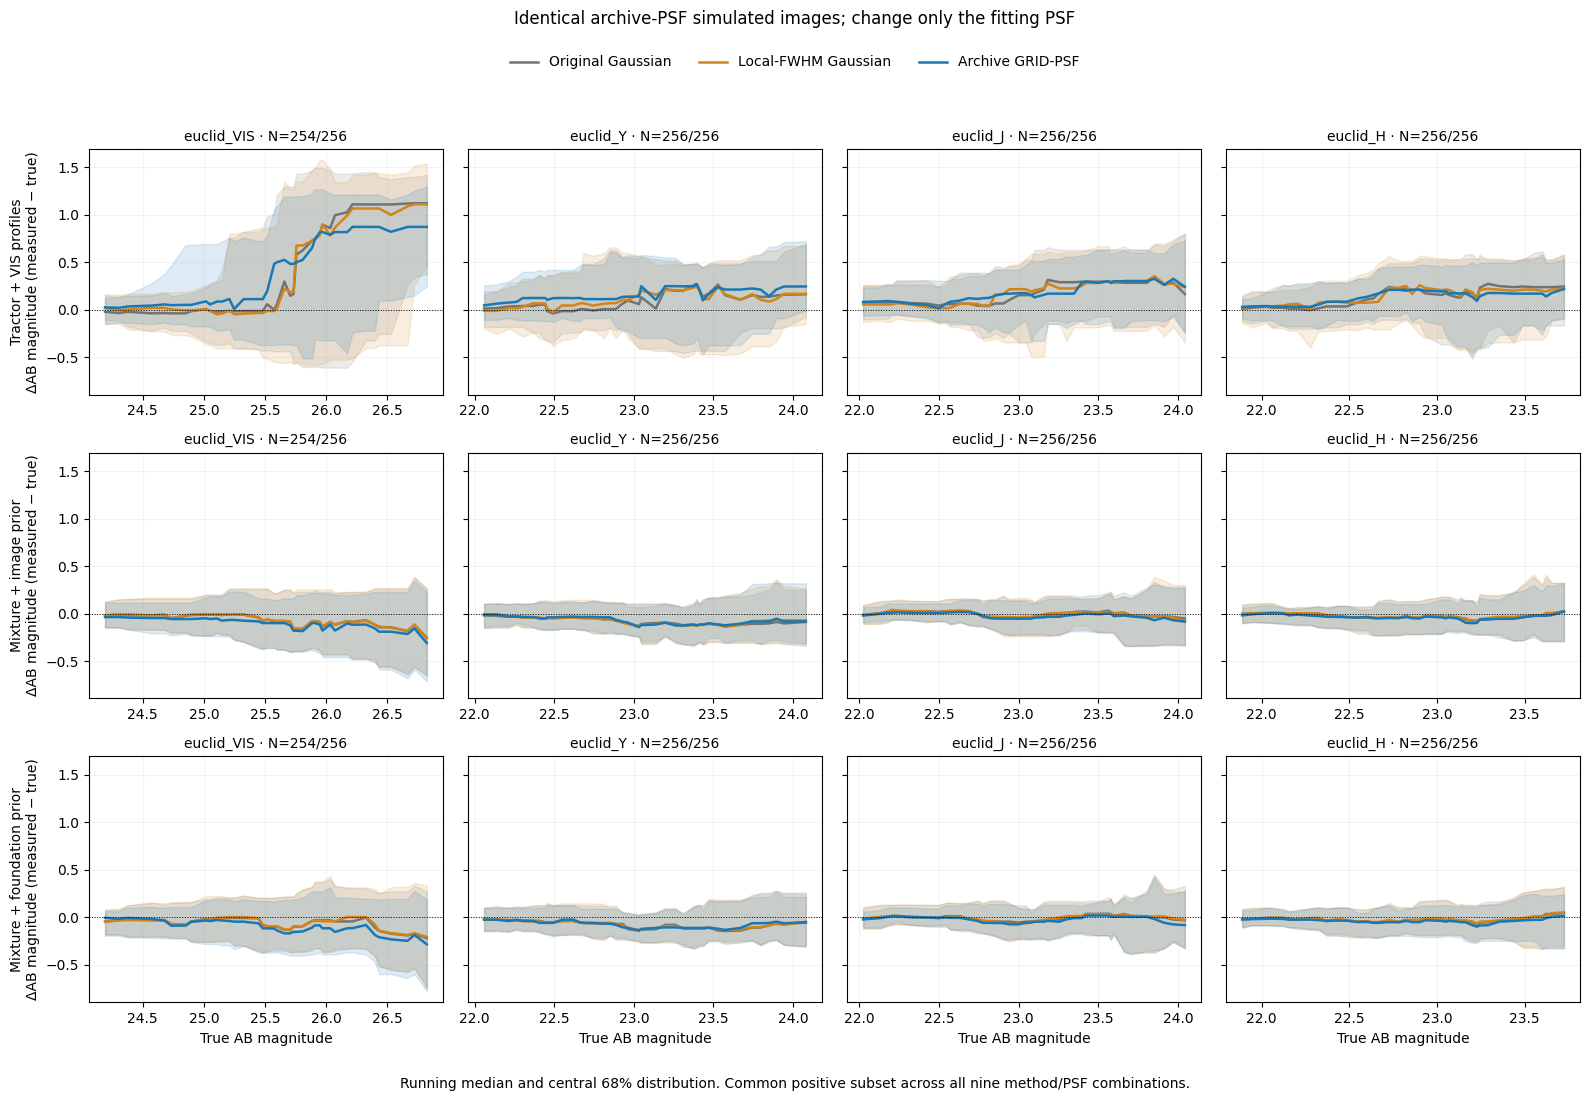

,band,total,common_positive
0,euclid_VIS,256,254
1,euclid_Y,256,256
2,euclid_J,256,256
3,euclid_H,256,256


condition               core_gaussian  gaussian   grid
model       band                                      
foundation  euclid_H             9.34      9.44   9.55
            euclid_J             9.51      9.58   9.85
            euclid_VIS          18.46     18.53  18.26
            euclid_Y            13.60     13.79  12.94
            rubin_g              7.75      7.78   7.82
            rubin_i              5.92      6.18   5.96
            rubin_r              7.39      7.41   7.36
            rubin_u             16.55     16.55  15.66
            rubin_y             12.76     12.72  12.77
            rubin_z             10.01     10.28   9.22
image       euclid_H             9.99     10.44   9.76
            euclid_J             9.87      9.80   9.50
            euclid_VIS          18.29     17.94  18.29
            euclid_Y            13.24     12.78  12.00
            rubin_g              8.27      8.15   8.59
            rubin_i              6.78      6.72   6.82
            rubin_r              7.39      7.59   7.47
            rubin_u             16.33     16.53  15.69
            rubin_y             13.92     13.96  13.31
            rubin_z              9.12      8.93   8.21
tractor_vis euclid_H            22.74     20.24  18.02
            euclid_J            22.73     22.18  20.06
            euclid_VIS          46.33     44.90  41.89
            euclid_Y            23.46     21.60  21.92
            rubin_g             11.03      9.89   9.62
            rubin_i             11.14      9.83   9.54
            rubin_r             10.94      9.72   9.51
            rubin_u             15.30     13.42  15.30
            rubin_y             14.68     14.21  13.22
            rubin_z             12.00     11.71  10.91

In [3]:
for figure in figures[1:]:
    display(figure); plt.close(figure)
display(pd.read_csv(OUT/'magnitude_selection.csv'))
print('All-band signed flux results (Rubin PSFs unchanged):')
display(stats.pivot(index=['model','band'], columns='condition', values='median_absolute_error_percent').round(2))

## Scope and reproduction

This is a **matched-PSF sensitivity test in one local field**, not real-survey accuracy validation. The grid truth and grid fitter intentionally share the same finite archive PSF. Normalizing finite stamps follows the upstream convention and does not recover missing far-wing light. The existing learned priors were trained with Gaussian image fits; retraining with empirical PSFs is a separate experiment.

The earlier benchmark had Gaussian PSFs in both truth and fitting. Thus an unmodeled real PSF cannot explain its entire Tractor/mixture gap; this new experiment checks whether the result changes when the image model is more realistic. Neither experiment alone establishes an incremental benefit from foundation features.

From the repository root:

```bash
python -m models.photometry.self_supervised.fetch_psf_study
OPENBLAS_NUM_THREADS=1 OMP_NUM_THREADS=1 python -m models.photometry.self_supervised.psf_study --count 128
# Repeat the next command for gaussian, core_gaussian and grid:
OPENBLAS_NUM_THREADS=1 OMP_NUM_THREADS=1 models/photometry/self_supervised/runs/tractor_env/bin/python -m models.photometry.self_supervised.tractor_compare --run models/photometry/self_supervised/runs/psf_study/grid --workers 2
```

Use the existing isolated Tractor setup documented in `nb_tractor_comparison.ipynb`. Archive access is needed only for the initial PSF fetch. Run `python -m models.photometry.self_supervised.fetch_ab_calibration` once to fetch and verify image zero points. Source-level results, failures, selected stamp coordinates/distances, paired statistics, and PNG/PDF plots are under `runs/psf_study/`.
